[![UAEM](https://www.uaem.mx/fcaei/images/uaem.png)](https://www.uaem.mx/fcaei/moca.html)
[![Python 3.9](https://img.shields.io/badge/Python-3.9-blue.svg)](https://www.python.org/downloads/release/python-390/)
[![Status](https://img.shields.io/badge/Status-En%20Progreso-yellow.svg)]()

# Tarea: Distribución Normal e Intervalos de Confianza

**Alumno:** Emiliano Rodriguez Villegas

**Fecha:** 18 de Septiembre de 2025
**Versión:** 1.0

---

## Introducción y Objetivo

Este notebook presenta un análisis estadístico descriptivo del conjunto de datos `AirQualityCleaned.csv`. El objetivo principal es cumplir con los requisitos de la tarea, que consisten en calcular, presentar e interpretar las **medidas de tendencia central** (media, mediana, moda) y las **medidas de dispersión** (varianza, desviación estándar, rango y rango intercuartílico) para las variables cuantitativas del dataset.


- Aplicar el cálculo de intervalos de confianza de la media.  
- Comparar cómo cambia el intervalo de confianza según el tamaño de la muestra.  
- Visualizar la relación entre **variabilidad, tamaño de muestra e incertidumbre**.  



---

---

## <a id='fase-1'></a>Fase 1: Preparación del Entorno y Carga de Datos

En esta primera fase, importaremos las librerías necesarias y cargaremos el dataset `AirQualityCleaned.csv` usando una variable para la ruta del archivo.

### <a id='1-1'></a>1.1. Importación de Librerías

Aquí se importan las bibliotecas de Python que utilizaremos a lo largo del notebook.


In [1]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### <a id='1-2'></a>1.2. Carga del Conjunto de Datos
Se carga el archivo AirQualityCleaned.csv en un DataFrame de Pandas para poder trabajar con él.

In [2]:
import pandas as pd
rutaDatos = '../Data/Air_Quality.csv'
dataFrame = pd.read_csv(rutaDatos)

### <a id='1-3'></a>1.3. Exploración Inicial de los Datos
Realizamos una revisión rápida del DataFrame para entender su estructura, las columnas que contiene y los tipos de datos.

In [3]:
dataFrame.head()


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
0,2024-01-01 00:00:00+00:00,Brasilia,323.0,NaN,23.8,2.8,42.0,12.0,17.1,16.800000
1,2024-01-01 01:00:00+00:00,Brasilia,318.0,NaN,21.9,2.7,40.0,12.5,17.9,16.000000
2,2024-01-01 02:00:00+00:00,Brasilia,309.0,NaN,19.2,2.6,39.0,12.1,17.3,15.599999
3,2024-01-01 03:00:00+00:00,Brasilia,295.0,NaN,16.3,2.4,38.0,11.4,16.2,15.200000
4,2024-01-01 04:00:00+00:00,Brasilia,270.0,NaN,13.0,2.1,40.0,10.2,14.6,16.000000


In [4]:
dataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52704 entries, 0 to 52703
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    52704 non-null  object 
 1   City    52704 non-null  object 
 2   CO      52704 non-null  float64
 3   CO2     9648 non-null   float64
 4   NO2     52704 non-null  float64
 5   SO2     52704 non-null  float64
 6   O3      52704 non-null  float64
 7   PM2.5   52704 non-null  float64
 8   PM10    52704 non-null  float64
 9   AQI     52704 non-null  float64
dtypes: float64(8), object(2)
memory usage: 4.0+ MB


---

## <a id='fase-2'></a>Fase 2: Cálculo de Medidas Estadísticas

Tarea: calcular las medidas estadísticas solicitadas para todas las variables cuantitativas identificadas.

### <a id='2-1'></a>2.1. Identificación de Variables Cuantitativas

Primero, identificamos cuáles de las columnas del `dataFrame` son numéricas (cuantitativas), ya que sobre estas realizaremos los cálculos.



In [5]:

variablesCuantitativas = dataFrame.select_dtypes(include=np.number)

print("Variables cuantitativas:")
print(variablesCuantitativas.columns.tolist())

Variables cuantitativas:
['CO', 'CO2', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'AQI']


### <a id='2-2'></a>2.2. Medidas de Tendencia Central
Calculamos la media, mediana y moda para cada variable cuantitativa.

In [6]:
media = variablesCuantitativas.mean()
mediana = variablesCuantitativas.median()
moda = variablesCuantitativas.mode().iloc[0]


print("--- Medidas de Tendencia Central ---")
print("\nMedia:\n", media)
print("\nMediana:\n", mediana)
print("\nModa:\n", moda)

--- Medidas de Tendencia Central ---

Media:
 CO       258.258121
CO2      462.348259
NO2       24.102998
SO2       12.569869
O3        60.025729
PM2.5     17.689931
PM10      35.643143
AQI       41.349339
dtype: float64

Mediana:
 CO       213.000000
CO2      453.000000
NO2       18.900000
SO2        5.700000
O3        54.000000
PM2.5     12.500000
PM10      18.900000
AQI       31.270835
dtype: float64

Moda:
 CO       175.0
CO2      445.0
NO2       10.3
SO2        1.4
O3        54.0
PM2.5      8.4
PM10      12.3
AQI       21.6
Name: 0, dtype: float64


### <a id='2-3'></a>2.3. Medidas de Dispersión

Calculamos la varianza, desviación estándar, rango y rango intercuartílico (IQR).

In [7]:
# Cálculo de la varianza
varianza = variablesCuantitativas.var()

# Cálculo de la desviación estándar
desviacionEstandar = variablesCuantitativas.std()




print("--- Medidas de Dispersión ---")
print("\nVarianza:\n", varianza)
print("\nDesviación Estándar:\n", desviacionEstandar)



--- Medidas de Dispersión ---

Varianza:
 CO       25468.953087
CO2       1140.345999
NO2        374.942943
SO2        298.136276
O3        1460.565719
PM2.5      245.551259
PM10      2346.896150
AQI        708.951820
dtype: float64

Desviación Estándar:
 CO       159.589953
CO2       33.769009
NO2       19.363443
SO2       17.266623
O3        38.217348
PM2.5     15.670075
PM10      48.444774
AQI       26.626149
dtype: float64


In [8]:

# Cálculo del rango (Máximo - Mínimo)
rango = variablesCuantitativas.max() - variablesCuantitativas.min()

# Cálculo del Rango Intercuartílico (IQR)
q1 = variablesCuantitativas.quantile(0.25)
q3 = variablesCuantitativas.quantile(0.75)
iqr = q3 - q1

print("\nRango Intercuartílico (IQR):\n", iqr)
print("\nRango:\n", rango)


Rango Intercuartílico (IQR):
 CO       147.000000
CO2       22.000000
NO2       23.700000
SO2       14.500000
O3        43.000000
PM2.5     16.100000
PM10      27.300000
AQI       34.902089
dtype: float64

Rango:
 CO       1993.00000
CO2       450.00000
NO2       165.90000
SO2       239.70000
O3        349.00000
PM2.5     129.40000
PM10      543.80000
AQI       192.18333
dtype: float64


### <a id='2-4'></a>2.4. Tabla de Resultados

In [9]:
# Crear un nuevo DataFrame para almacenar los resultados
tablaResultados = pd.DataFrame({
    'Media': media,
    'Mediana': mediana,
    'Moda': moda,
    'Varianza': varianza,
    'DesviacionEstandar': desviacionEstandar,
    'Rango': rango,
    'IQR': iqr
})


tablaResultados

,Media,Mediana,Moda,Varianza,DesviacionEstandar,Rango,IQR
CO,258.258121,213.000000,175.0,25468.953087,159.589953,1993.00000,147.000000
CO2,462.348259,453.000000,445.0,1140.345999,33.769009,450.00000,22.000000
NO2,24.102998,18.900000,10.3,374.942943,19.363443,165.90000,23.700000
SO2,12.569869,5.700000,1.4,298.136276,17.266623,239.70000,14.500000
O3,60.025729,54.000000,54.0,1460.565719,38.217348,349.00000,43.000000
PM2.5,17.689931,12.500000,8.4,245.551259,15.670075,129.40000,16.100000
PM10,35.643143,18.900000,12.3,2346.896150,48.444774,543.80000,27.300000
AQI,41.349339,31.270835,21.6,708.951820,26.626149,192.18333,34.902089


## <a id='fase-3'></a>Fase 3: Visualización de Datos

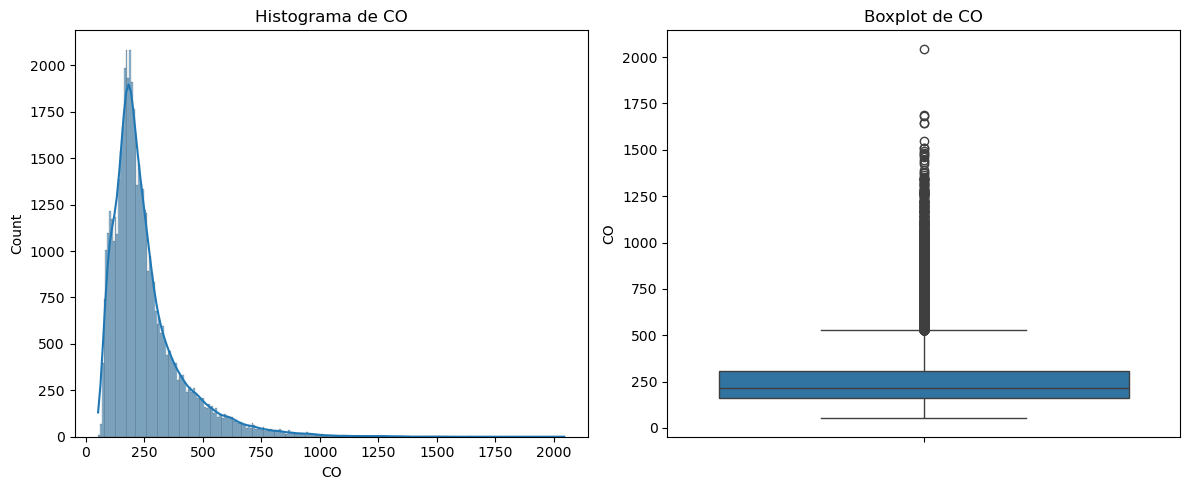

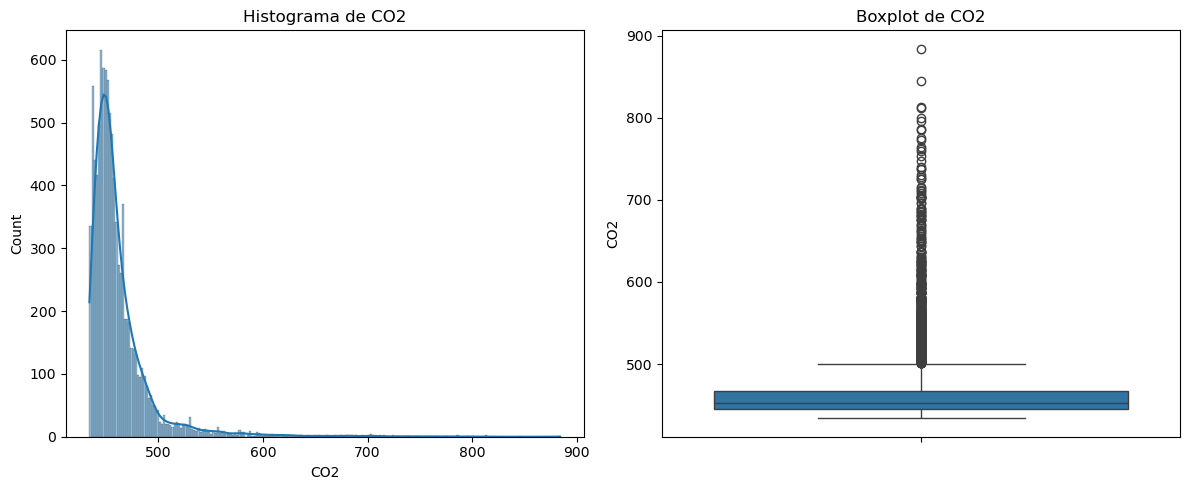

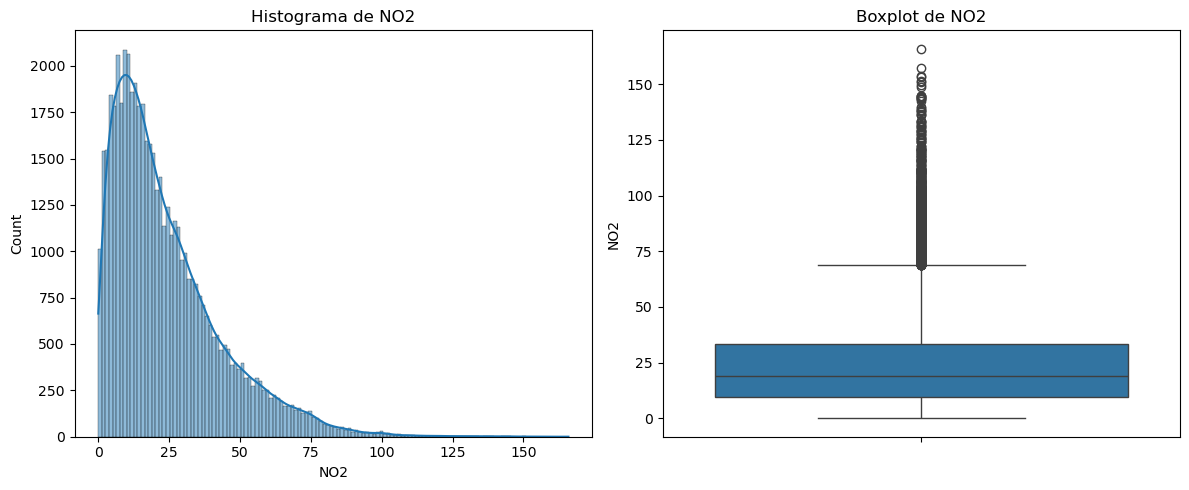

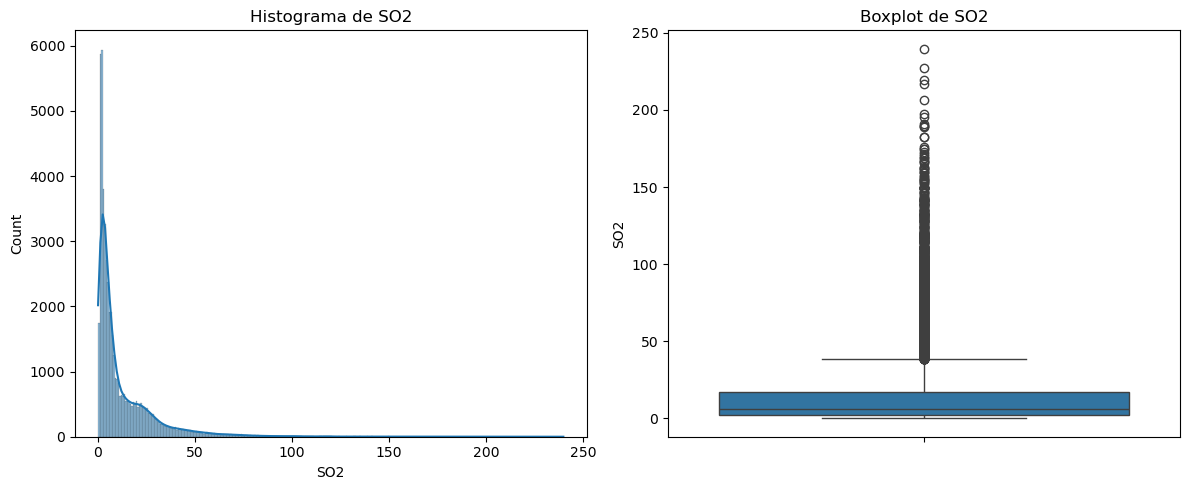

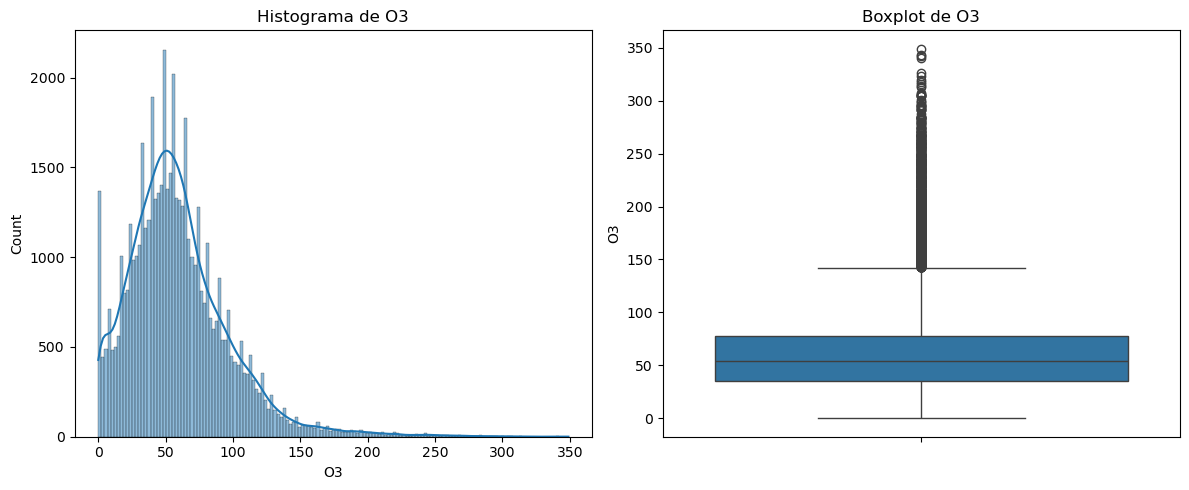

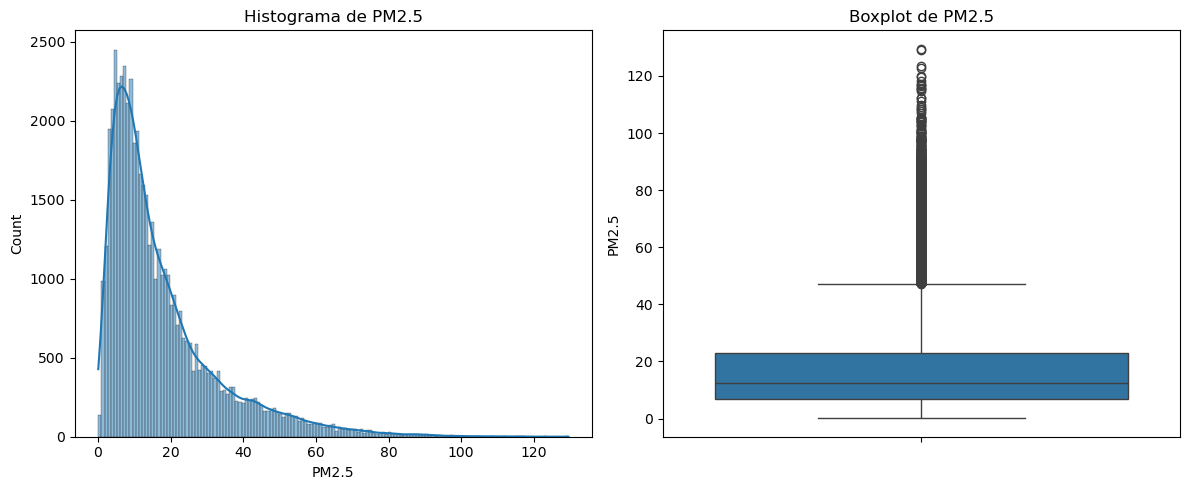

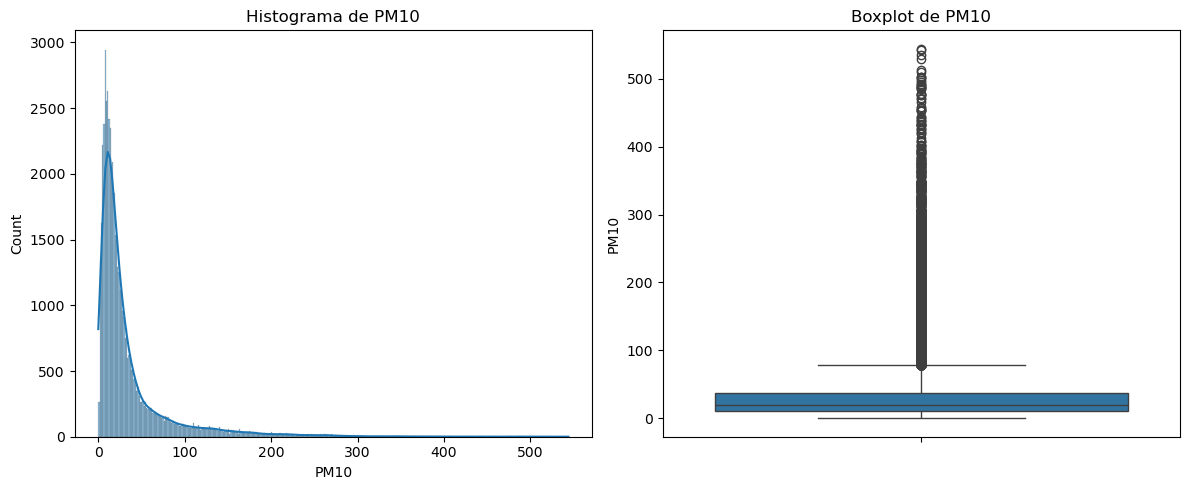

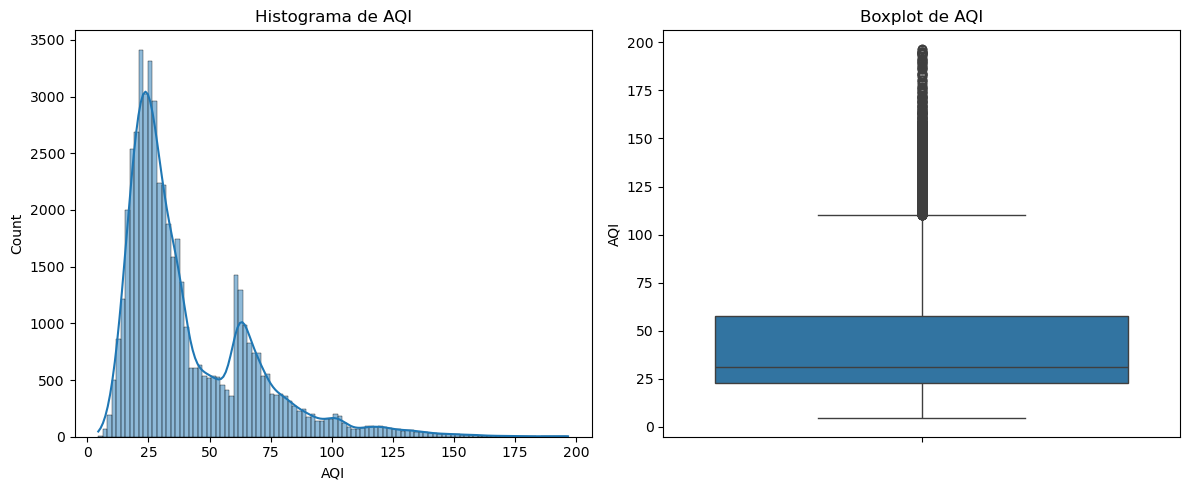

In [10]:
for col in variablesCuantitativas.columns:

    plt.figure(figsize=(12, 5))
    

    plt.subplot(1, 2, 1)
    sns.histplot(data=variablesCuantitativas, x=col, kde=True)
    plt.title(f'Histograma de {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(data=variablesCuantitativas, y=col)
    plt.title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()

Considero que la variable que nos muestra una mejor distribucion "normal" es la variable AQI

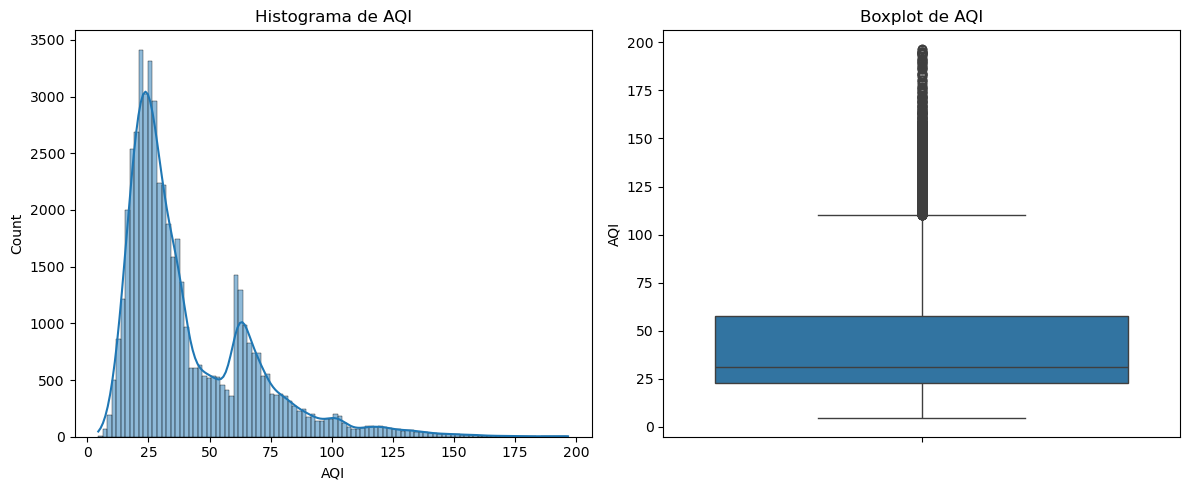

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=variablesCuantitativas, x='AQI', kde=True)
plt.title('Histograma de AQI')

plt.subplot(1, 2, 2)
sns.boxplot(data=variablesCuantitativas, y='AQI')
plt.title('Boxplot de AQI')

plt.tight_layout()
plt.show()

In [12]:
aqi = variablesCuantitativas[col]
media_muestral = aqi.mean()

desviacion_muestral = aqi.std(ddof=1)

# error estándar
n = aqi.count()
error_estandar = desviacion_muestral / np.sqrt(n)

print(f"Media muestral (x̄): {media_muestral}")
print(f"Desviación estándar muestral (s): {desviacion_muestral}")
print(f"Error estándar: {error_estandar}")

Media muestral (x̄): 41.34933870882476
Desviación estándar muestral (s): 26.626149183110183
Error estándar: 0.11598092609822852


Media muestral de AQI: 41.35
IC 95%: (41.12202027077863, 41.57665714687089)


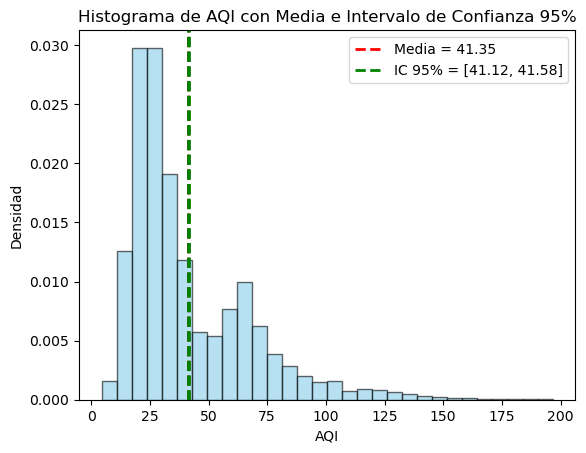

In [13]:
from scipy import stats

aqi = variablesCuantitativas[col]
aqi_data = aqi.dropna()
n_aqi = aqi_data.count()
media_aqi = aqi_data.mean()
std_aqi = aqi_data.std(ddof=1)
se_aqi = std_aqi / np.sqrt(n_aqi)

# Intervalo de confianza al 95%
ci_aqi = stats.norm.interval(0.95, loc=media_aqi, scale=se_aqi)

print(f"Media muestral de AQI: {media_aqi:.2f}")
print(f"IC 95%: {ci_aqi}")

# Gráfico: histograma + media + IC
plt.hist(aqi_data, bins=30, density=True, alpha=0.6, color="skyblue", edgecolor="black")

plt.axvline(media_aqi, color="red", linestyle="--", linewidth=2, label=f"Media = {media_aqi:.2f}")
plt.axvline(ci_aqi[0], color="green", linestyle="--", linewidth=2, label=f"IC 95% = [{ci_aqi[0]:.2f}, {ci_aqi[1]:.2f}]")
plt.axvline(ci_aqi[1], color="green", linestyle="--", linewidth=2)

plt.title("Histograma de AQI con Media e Intervalo de Confianza 95%")
plt.xlabel("AQI")
plt.ylabel("Densidad")
plt.legend()
plt.show()

In [14]:

alpha = 0.05  # lvl significancia para IC del 95%
gl = n_aqi - 1
# Vcrítico t para dos colas
t_critico = stats.t.ppf(1 - alpha/2, gl)

#Iconfianza al 95% usando t de Student
limite_inferior = media_aqi - t_critico * se_aqi
limite_superior = media_aqi + t_critico * se_aqi

print(f"t crítico (tα/2, n-1): {t_critico:.4f}")
print(f"IC 95% para la media de AQI usando t de Student: [{limite_inferior:.4f}, {limite_superior:.4f}]")

t crítico (tα/2, n-1): 1.9600
IC 95% para la media de AQI usando t de Student: [41.1220, 41.5767]


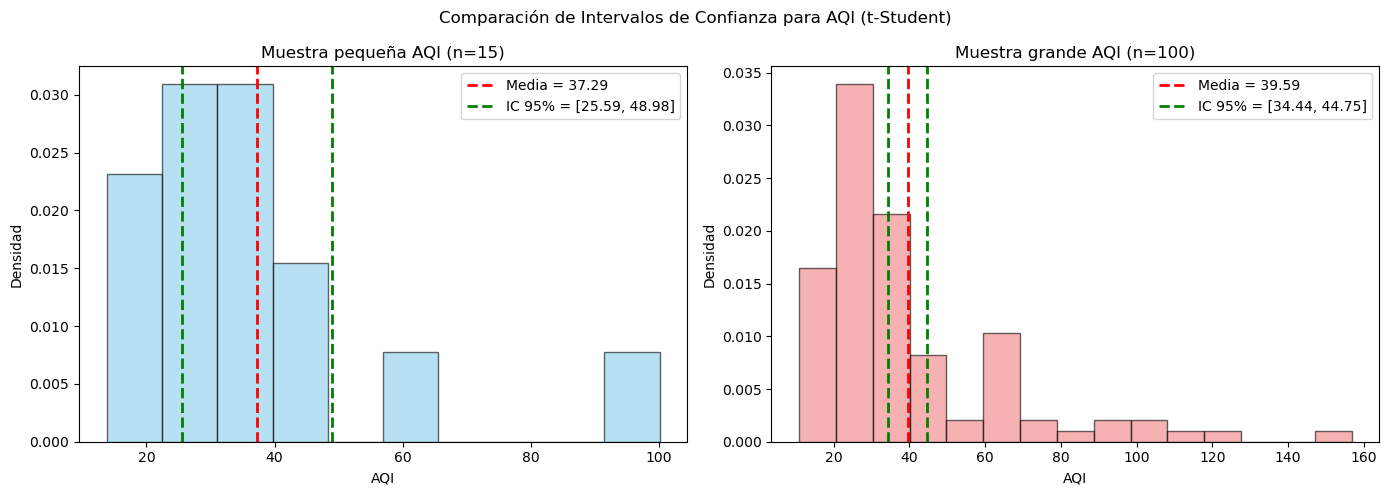

In [15]:


def calcular_ic(data, alpha=0.05):
    n = len(data)
    mean_sample = np.mean(data)
    std_sample = np.std(data, ddof=1)
    se = std_sample / np.sqrt(n)
    df = n - 1
    t_crit = stats.t.ppf(1 - alpha/2, df)
    ci_lower = mean_sample - t_crit * se
    ci_upper = mean_sample + t_crit * se
    return mean_sample, ci_lower, ci_upper

# Muestras de AQI: pequeña y grande
np.random.seed(42)
aqi_small = aqi.sample(15, random_state=42)
aqi_large = aqi.sample(100, random_state=42)

# Calcular ICs
mean_s, ci_s_l, ci_s_u = calcular_ic(aqi_small, alpha)
mean_l, ci_l_l, ci_l_u = calcular_ic(aqi_large, alpha)

# Graficar comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma muestra pequeña
axes[0].hist(aqi_small, bins=10, alpha=0.6, color="skyblue", edgecolor="black", density=True)
axes[0].axvline(mean_s, color="red", linestyle="--", linewidth=2, label=f"Media = {mean_s:.2f}")
axes[0].axvline(ci_s_l, color="green", linestyle="--", linewidth=2, label=f"IC 95% = [{ci_s_l:.2f}, {ci_s_u:.2f}]")
axes[0].axvline(ci_s_u, color="green", linestyle="--", linewidth=2)
axes[0].set_title("Muestra pequeña AQI (n=15)")
axes[0].set_xlabel("AQI")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# Histograma muestra grande
axes[1].hist(aqi_large, bins=15, alpha=0.6, color="lightcoral", edgecolor="black", density=True)
axes[1].axvline(mean_l, color="red", linestyle="--", linewidth=2, label=f"Media = {mean_l:.2f}")
axes[1].axvline(ci_l_l, color="green", linestyle="--", linewidth=2, label=f"IC 95% = [{ci_l_l:.2f}, {ci_l_u:.2f}]")
axes[1].axvline(ci_l_u, color="green", linestyle="--", linewidth=2)
axes[1].set_title("Muestra grande AQI (n=100)")
axes[1].set_xlabel("AQI")
axes[1].set_ylabel("Densidad")
axes[1].legend()

plt.suptitle("Comparación de Intervalos de Confianza para AQI (t-Student)")
plt.tight_layout()
plt.show()

IC para muestra pequeña (n=30):
Media: 39.50, IC 95%: [30.22, 48.79]

IC para muestra grande (n=100):
Media: 39.59, IC 95%: [34.44, 44.75]

IC para el total de datos:
Media: 41.35, IC 95%: [41.12, 41.58]


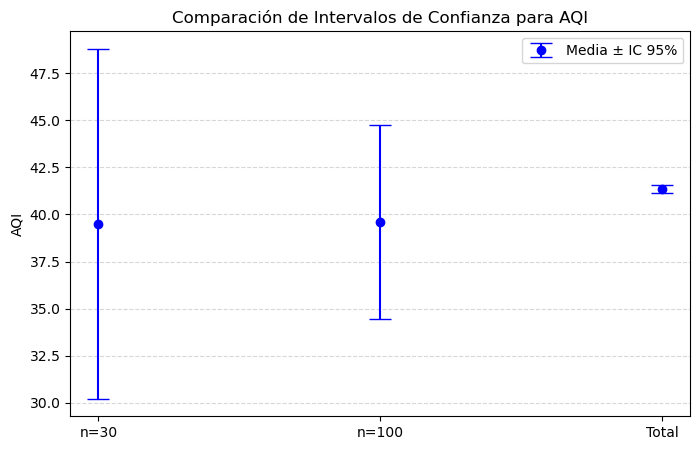

In [16]:
# Submuestra pequeña (n=30)
np.random.seed(42)
aqi_n30 = aqi.sample(30, random_state=42)
mean_30, ci_30_l, ci_30_u = calcular_ic(aqi_n30, alpha)

# Submuestra grande (n=100)
# Ya existe: aqi_large, mean_l, ci_l_l, ci_l_u

# Total de datos
mean_total, ci_total_l, ci_total_u = calcular_ic(aqi, alpha)

print("IC para muestra pequeña (n=30):")
print(f"Media: {mean_30:.2f}, IC 95%: [{ci_30_l:.2f}, {ci_30_u:.2f}]")
print("\nIC para muestra grande (n=100):")
print(f"Media: {mean_l:.2f}, IC 95%: [{ci_l_l:.2f}, {ci_l_u:.2f}]")
print("\nIC para el total de datos:")
print(f"Media: {mean_total:.2f}, IC 95%: [{ci_total_l:.2f}, {ci_total_u:.2f}]")

# Visualización comparativa
plt.figure(figsize=(8, 5))
plt.errorbar(['n=30', 'n=100', 'Total'],
             [mean_30, mean_l, mean_total],
             yerr=[mean_30 - ci_30_l, mean_l - ci_l_l, mean_total - ci_total_l],
             fmt='o', capsize=8, color='blue', label='Media ± IC 95%')
plt.title('Comparación de Intervalos de Confianza para AQI')
plt.ylabel('AQI')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

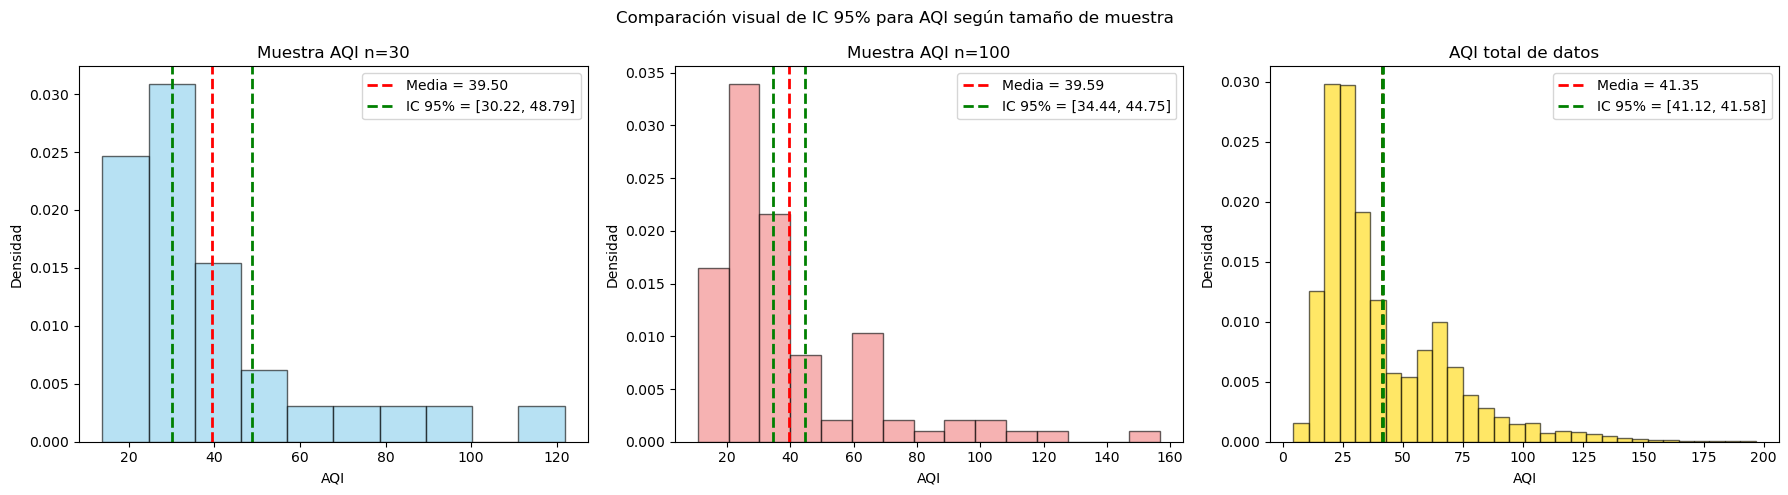

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# n=30
axes[0].hist(aqi_n30, bins=10, alpha=0.6, color="skyblue", edgecolor="black", density=True)
axes[0].axvline(mean_30, color="red", linestyle="--", linewidth=2, label=f"Media = {mean_30:.2f}")
axes[0].axvline(ci_30_l, color="green", linestyle="--", linewidth=2, label=f"IC 95% = [{ci_30_l:.2f}, {ci_30_u:.2f}]")
axes[0].axvline(ci_30_u, color="green", linestyle="--", linewidth=2)
axes[0].set_title("Muestra AQI n=30")
axes[0].set_xlabel("AQI")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# n=100
axes[1].hist(aqi_large, bins=15, alpha=0.6, color="lightcoral", edgecolor="black", density=True)
axes[1].axvline(mean_l, color="red", linestyle="--", linewidth=2, label=f"Media = {mean_l:.2f}")
axes[1].axvline(ci_l_l, color="green", linestyle="--", linewidth=2, label=f"IC 95% = [{ci_l_l:.2f}, {ci_l_u:.2f}]")
axes[1].axvline(ci_l_u, color="green", linestyle="--", linewidth=2)
axes[1].set_title("Muestra AQI n=100")
axes[1].set_xlabel("AQI")
axes[1].set_ylabel("Densidad")
axes[1].legend()

# Total 
axes[2].hist(aqi, bins=30, alpha=0.6, color="gold", edgecolor="black", density=True)
axes[2].axvline(mean_total, color="red", linestyle="--", linewidth=2, label=f"Media = {mean_total:.2f}")
axes[2].axvline(ci_total_l, color="green", linestyle="--", linewidth=2, label=f"IC 95% = [{ci_total_l:.2f}, {ci_total_u:.2f}]")
axes[2].axvline(ci_total_u, color="green", linestyle="--", linewidth=2)
axes[2].set_title("AQI total de datos")
axes[2].set_xlabel("AQI")
axes[2].set_ylabel("Densidad")
axes[2].legend()

plt.suptitle("Comparación visual de IC 95% para AQI según tamaño de muestra")
plt.tight_layout()
plt.show()

---

## <a id='fase-4'></a>Fase 4: Interpretación y Conclusiones

Interpretacion de los datos

### <a id='4-1'></a>4.1. Interpretación de Resultados

# Análisis de Intervalos de Confianza (IC) para el AQI

A continuación se detalla la relación entre la anchura del intervalo de confianza, la incertidumbre y el tamaño de la muestra, basándonos en los datos obtenidos sobre el Índice de Calidad del Aire (AQI).

---

## 1. ¿Qué representa la anchura del IC en términos de incertidumbre?

La **anchura del intervalo de confianza (IC)** es una medida directa de la **incertidumbre** de nuestra estimación. 

* Un **intervalo más ancho** implica **mayor incertidumbre**. Significa que tenemos menos certeza sobre dónde se encuentra el verdadero valor promedio de la población.
* Un **intervalo más estrecho** implica **menor incertidumbre** y, por lo tanto, una estimación más precisa.

En tus datos, podemos observar esto claramente al comparar la anchura de los intervalos:

* **Muestra pequeña (n=30):** IC 95% = [30.22, 48.79]. La anchura es de **18.57**. Este es el intervalo más amplio, lo que refleja la mayor incertidumbre.
* **Muestra grande (n=100):** IC 95% = [34.44, 44.75]. La anchura es de **10.31**. El intervalo se ha reducido, indicando una estimación más precisa.
* **Total de datos:** IC 95% = [41.12, 41.58]. La anchura es de solo **0.46**. Este es el intervalo más estrecho, lo que representa la menor incertidumbre y la estimación más precisa de la media.



---

## 2. ¿Cómo cambia el IC al aumentar el tamaño de la muestra?

El intervalo de confianza **se vuelve más estrecho a medida que aumenta el tamaño de la muestra**. 📏

Esta es una relación inversa: a más datos, menor es el error de la estimación y, por lo tanto, el rango de valores probables para la media de la población se reduce. Tus gráficos ilustran perfectamente este principio estadístico.

| Tamaño de la muestra (n) | Media | Intervalo de Confianza (95%) | Anchura del IC |
| :----------------------- | :---- | :--------------------------- | :------------- |
| n=30                     | 39.50 | [30.22, 48.79]               | 18.57          |
| n=100                    | 39.59 | [34.44, 44.75]               | 10.31          |
| Total                    | 41.35 | [41.12, 41.58]               | 0.46           |

Como se ve en la tabla y en las gráficas, al pasar de una muestra de 30 a 100, el intervalo se reduce considerablemente. Al usar el conjunto total de datos, obtenemos la estimación más precisa y el intervalo más angosto posible.

# ¿Por Qué Transformamos Variables a Formato Categórico?

En el análisis de datos, a menudo tenemos variables continuas (como el `AQI`) o de series de tiempo (como la `Fecha`). Aunque son muy ricas en información, a veces es necesario agruparlas en **categorías** para poder realizar ciertos tipos de análisis y facilitar la interpretación.

En este proyecto, se realizaron dos transformaciones clave por las siguientes razones:

---

### 1. Para Poder Usar Pruebas Estadísticas Específicas (Como Chi-Cuadrada) 

Algunas de las pruebas estadísticas más potentes, como la **prueba de independencia de Chi-cuadrada (χ²)**, están diseñadas para trabajar exclusivamente con **datos categóricos**.

* **¿Qué hace la prueba?** Chi-cuadrada no mide cómo una variable numérica sube o baja junto con otra. En su lugar, compara las **frecuencias** de las observaciones dentro de diferentes grupos para ver si existe una asociación.
* **Nuestro caso de uso:** Para responder a la pregunta "¿La calidad del aire *depende* de la estación del año?", necesitábamos contar cuántos días de cada *categoría de AQI* caían dentro de cada *categoría de estación*. Esto es imposible de hacer con fechas exactas y valores numéricos de AQI.

---

### 2. Para Simplificar la Complejidad y Descubrir Patrones 

Los datos en su forma original pueden ser demasiado detallados para ver patrones a simple vista. La categorización nos ayuda a "alejar el zoom" y observar tendencias generales.

* **De Fechas a Estaciones:** Analizar 365 días individuales es complejo. Agruparlos en 4 estaciones (`Invierno`, `Primavera`, `Verano`, `Otoño`) nos permite comparar bloques de tiempo significativos y descubrir patrones estacionales, como que la contaminación empeora en verano.
* **De Números a Niveles de Riesgo:** Un AQI de 155 y uno de 195 son numéricamente diferentes, pero ambos caen en la categoría **"Dañina"**. Al agruparlos, podemos contar el número total de días que representaron un riesgo similar para la salud, lo cual es más útil para el análisis práctico que simplemente promediar los números.

---

### 3. Para Facilitar la Interpretación y Comunicación de Resultados 

Los resultados de un análisis son más impactantes cuando son fáciles de entender. Las categorías nos ayudan a contar una historia más clara.

Es mucho más efectivo y comprensible decir:
> "El verano tuvo 193 días con calidad de aire 'Dañina', mientras que la primavera no tuvo ninguno."

Que decir algo como:
> "El promedio del AQI en los días de verano fue de X, mientras que en los de primavera fue de Y."

Las etiquetas categóricas (`Buena`, `Moderada`, `Dañina`) añaden un **contexto inmediato** que los números por sí solos no tienen.

### Resumen de la Transformación

| Variable Original | Tipo Original | Variable Transformada | Tipo Nuevo | Propósito del Cambio |
| :--- | :--- | :--- | :--- | :--- |
| `Date` | Fecha/Hora | `Estacion` | Categórica | Agrupar los datos para encontrar patrones estacionales. |
| `AQI` | Numérica Continua | `CategoriaAQI` | Categórica Ordinal | Agrupar por nivel de riesgo para la salud y facilitar la interpretación. |

In [18]:
# v categorica: estación del año
# formato YYYY-MM-DD
def obtener_estacion(fecha):
    """Devuelve la estación del año para una fecha dada (hemisferio norte)."""
    mes = fecha.month
    dia = fecha.day
    if (mes == 12 and dia >= 21) or (mes <= 3 and (mes < 3 or (mes == 3 and dia < 21))):
        return 'Invierno'
    elif (mes == 3 and dia >= 21) or (mes < 6) or (mes == 6 and dia < 21):
        return 'Primavera'
    elif (mes == 6 and dia >= 21) or (mes < 9) or (mes == 9 and dia < 23):
        return 'Verano'
    elif (mes == 9 and dia >= 23) or (mes < 12) or (mes == 12 and dia < 21):
        return 'Otoño'
    else:
        return 'Invierno'


def categorizar_aqi(aqi):
    if 0 <= aqi <= 50:
        return 'Buena'
    elif 51 <= aqi <= 100:
        return 'Moderada'
    elif 101 <= aqi <= 150:
        return 'Dañina (Sensibles)'
    elif 151 <= aqi <= 200:
        return 'Dañina'
    elif 201 <= aqi <= 300:
        return 'Muy Dañina'
    
    else:
        return 'Peligrosa'

dataFrame['Date'] = pd.to_datetime(dataFrame['Date'])

dataFrame['Estacion'] = dataFrame['Date'].apply(obtener_estacion)
dataFrame['CategoriaAQI'] = dataFrame['AQI'].apply(categorizar_aqi)


print(dataFrame['Estacion'].value_counts())

Estacion
Verano       13536
Primavera    13248
Invierno     13104
Otoño        12816
Name: count, dtype: int64


In [19]:
tabla_contingencia = pd.crosstab(dataFrame['Estacion'], dataFrame['CategoriaAQI'])

print("--- Tabla de Contingencia ---")
print(tabla_contingencia)

--- Tabla de Contingencia ---
CategoriaAQI  Buena  Dañina  Dañina (Sensibles)  Moderada  Peligrosa
Estacion                                                            
Invierno       9035      13                 176      3789         91
Otoño          9545       0                  53      3141         77
Primavera      9408       0                 266      3495         79
Verano         9559     193                1360      2272        152


In [27]:
from scipy.stats import chi2_contingency
import pandas as pd

chi2, p_valor, _, tabla_esperada = chi2_contingency(tabla_contingencia)
tabla_esperada_df = pd.DataFrame(tabla_esperada, 
                                 index=tabla_contingencia.index, 
                                 columns=tabla_contingencia.columns)

print("\n--- Tabla de Frecuencias Esperadas ---")
print(tabla_esperada_df.round(2))


--- Tabla de Frecuencias Esperadas ---
CategoriaAQI    Buena  Dañina  Dañina (Sensibles)  Moderada  Peligrosa
Estacion                                                              
Invierno      9335.46   51.22              461.22   3156.90      99.20
Otoño         9130.28   50.09              451.08   3087.52      97.02
Primavera     9438.04   51.78              466.28   3191.60     100.30
Verano        9643.22   52.91              476.42   3260.98     102.48


In [28]:
from scipy.stats import chi2_contingency
chi2, p_valor, _, _ = chi2_contingency(tabla_contingencia)

print(f"\nEstadístico Chi-cuadrada: {chi2:.4f}")
print(f"P-valor: {p_valor:.4f}")


Estadístico Chi-cuadrada: 3272.6317
P-valor: 0.0000


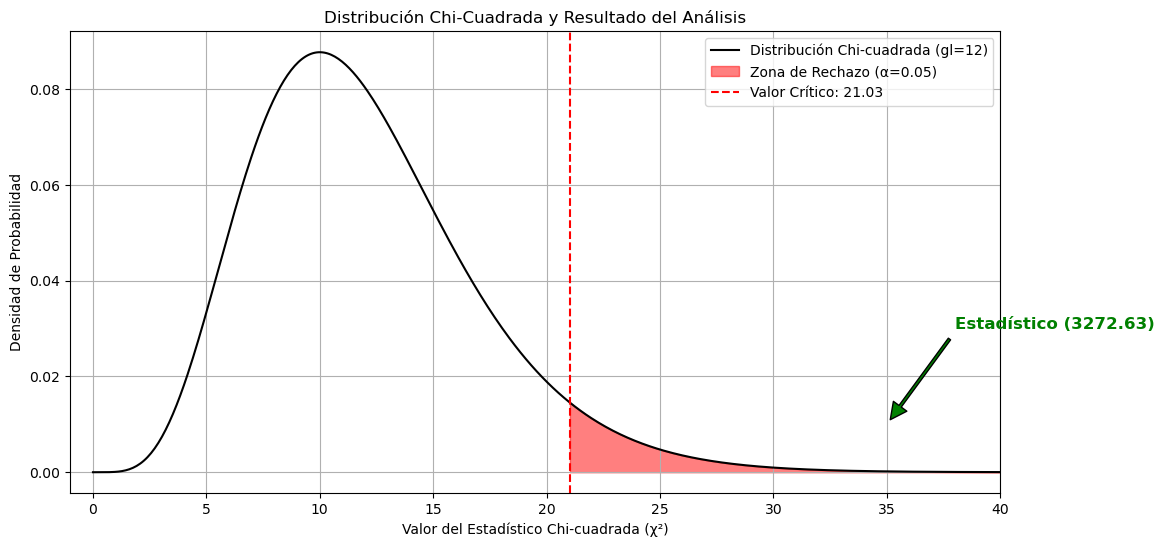

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

grados_libertad = 12
chi2_estadistico = 3272.6317 

x = np.linspace(0, 40, 500)
distribucion = chi2.pdf(x, df=grados_libertad)
valor_critico = chi2.ppf(0.95, df=grados_libertad)

plt.figure(figsize=(12, 6))
plt.plot(x, distribucion, color='black', label=f'Distribución Chi-cuadrada (gl={grados_libertad})')

x_rechazo = np.linspace(valor_critico, 40, 100)
y_rechazo = chi2.pdf(x_rechazo, df=grados_libertad)
plt.fill_between(x_rechazo, y_rechazo, color='red', alpha=0.5, label='Zona de Rechazo (α=0.05)')

plt.axvline(valor_critico, color='red', linestyle='--', label=f'Valor Crítico: {valor_critico:.2f}')

plt.annotate(
    f'Estadístico ({chi2_estadistico:.2f})', 
    xy=(35, 0.01),  
    xytext=(38, 0.03), 
    arrowprops=dict(facecolor='green', shrink=0.05, width=2),
    ha='left',
    color='green',
    fontsize=12,
    fontweight='bold'
)


plt.xlim(-1, 40)


plt.title('Distribución Chi-Cuadrada y Resultado del Análisis')
plt.xlabel('Valor del Estadístico Chi-cuadrada (χ²)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True)
plt.show()

# Análisis Chi-Cuadrada: Relación entre Estación y Calidad del Aire

Este análisis investiga si existe una dependencia entre la estación del año y la calidad del aire (AQI) en el dataset.

> **Pregunta de Investigación:** ¿Existe una asociación estadísticamente significativa entre la estación del año y la categoría de la calidad del aire?

---

## 1. Metodología

Se utilizó la **prueba de independencia de Chi-cuadrada (χ²)** para evaluar la relación entre dos variables categóricas:
* **Estación del Año:** (Invierno, Otoño, Primavera, Verano)
* **Categoría del AQI:** (Buena, Moderada, Dañina, etc.)

---

## 2. Resultados Estadísticos

Los resultados de la prueba fueron concluyentes:

* **Estadístico Chi-cuadrada (χ²):** 3272.63
* **P-valor:** 0.00000000 (`p < 0.001`)

El **p-valor**, al ser prácticamente cero y mucho menor que el nivel de significancia estándar (α = 0.05), nos permite rechazar la hipótesis nula de independencia.

**Conclusión:**  Existe una **asociación fuerte y estadísticamente significativa** entre la estación del año y la calidad del aire.

---

## 3. Análisis de los Patrones Observados

Al analizar la tabla de contingencia, se identificaron los siguientes patrones clave que explican esta relación:

*  **Verano:** Es la estación con la peor calidad del aire, mostrando la incidencia más alta de días clasificados como **'Dañina'**, **'Dañina (Sensibles)'** y **'Peligrosa'**.
*  **Invierno:** Se caracteriza por tener el mayor número de días con calidad del aire **'Moderada'**.
*  **Primavera y Otoño:** Emergen como las estaciones con la mejor calidad del aire. Destaca la **primavera**, que no registró **ningún día** en la categoría 'Dañina'.

---

## 4. Conclusión General

El análisis confirma que la calidad del aire en este dataset no es homogénea a lo largo del año. Se ha demostrado un patrón estacional claro, con un **deterioro notable de la calidad del aire durante el verano**.